# EDA con datos médicos & ML de arboles de decisión

* https://gemini.google.com/app/4b8a99c87f15c8b3?hl=es-ES

# **EDA para ML**

## Paso 0: **Setup básico: Imports & Read data**

> (1) **Importar librerías necesarias**  
>  
> (2) **Data Inical**  

### (1) **Importar librerías necesarias**  
> - pandas para cargar nuestros datos  
> - matplotlib y seaborn para crear graficos 


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### (2) **Data Inicial**

In [27]:
df = pd.read_csv("../data/raw/diabetes-data.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [28]:
df.info() # explorar datos

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Observaciones:**

> DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 768 filas y 9 columnas  
> * Los datos que aporta el datset son 9 columnas de tipo numérico (enteros y decimales)
> * ``dtypes``: float64(2), int64(7)

#### (2.1) **Definición del problema e información del conjunto de datos**

* **Planteamiento:** Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. 
* **Objetivo:** Predecir en base a medidas diagnósticas si un paciente tiene o no diabetes. Es importante tener en cuenta en este data-set que tratamos con datos médicos y no podemos inventar o elminar información que no este justificada ya que queremos obtener el minimo error en el resultado.

* **Varibales independientes**

COLUMNAS Y CARACTERÍSTICAS DE LAS VARIABLES

**1. NUMÉRICAS:**

> * Medicas:  
        - `Glucose`. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)  
        - `BloodPressure`. Presión arterial diastólica (medida en mm Hg) (numérico)  
        - `SkinThickness`. Grosor del pliegue cutáneo del tríceps. Según el grosos de la piel podemos detectar el nivel de grasa (obesidad del paciente) que es una condición que puede influir en la diabetes (medida en mm) (numérico)  
        - `Insulin`. Insulina sérica de 2 horas (medida en mu U/ml). La insulina sérica es la insulina presente en la sangre. Si los niveles son bajos entonces indica déficit de produccion de glucosa por lo tanto puede tratarse de diabetes avanzada. La insulina es la hormonoa que regula la absorción de la glucosa, por eso cuando es baja se presdenta como síntoma de diabetes. (numérico)  
        - `BMI`. Índice de masa corporal(IMC), relación entre el peso y la altura del paciente (numérico)

> * Persona:  
        - `Pregnancies`. Número de embarazos del paciente (numérico)  
        - `DiabetesPedigreeFunction`. Función de pedigrí de diabetes, es el historial genealógico o familiar que señala el riesgo hereditario. (numérico)  
        - `Age`. Edad del paciente (numérico)

**2. CATEGÓRICAS**  

* **Variable target** 
> ``Outcome``, es la variable que nos da el resultado del planteamiento del problema, si un paciente es diabetico o no. No se indica el tipo de diabetes de la persona.

**Observaciones:**

> Por ahora se usan todas las columnas para el análisis ya que todas son importantes para determinar si el paciente tiene diabetes o no.

## Paso 1: **Limpieza de datos**

### (1) **Valores NaNs**

¿Hay valores NaN? ¿Dónde? ¿Representarían información importante para el análisis?  

In [29]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


> No existen valores nulos.

### (2) **Valores duplicados**

In [30]:
df.duplicated().sum()

np.int64(0)

> No tenemos valores duplicados.

### (3) **Valores a 0**

In [31]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

**OBSERVACIONES DE LOS VALORES A 0:**

> * Indica que 11 pacientes con han estado nunca embarazadas (Pregnancies                 111)  
> * Son las columnas más relevantes: Glucose                       5  y  BMI                          11.  
> Junto a DiabetesPedigreeFunction      0  Age                           0 que no tienen valores nulos-  
>  
> * Las columnas con más valores a 0 sin sentido lógico son:    
> SkinThickness               227  
> Insulin                     374    
> BloodPressure                35 
> 
>  
> * Columna target: El 0 representa que 500 pacientes 1 si o no 0 tiene diabetes.  
> Outcome                     500, hay 500 pacientes que no tienen diabtes.



#### **Conclusiones**

> * En las columnas con más valores a 0 son Insulin y SkinThickness. Esos valores representan más de la mitad del dataset, es posible que no se tomaran los datos durante las pruebas. Para el análisis podríamos pasarlos a valores NaN sin necesidad de eliminar las columnas pero no la utilizaría para el ML ya que representan alarededor de la mitad de la data de valores nulos.  
>  
> * Decido eliminar las filas que contienen valores zero en las dos últimsa columnas mencionadas y también las filas a 0 de la columna BloodPressure ya que es imposible en un ser humano si la persona está viva, por eso la columna Glucosa y BMI adquieren mayor importancia.



* **Limpieza de filas con valores nulos:**

In [32]:
df = df.drop(df[(df['BMI'] == 0) & (df['Glucose'] == 0) & (df['BloodPressure'] == 0)].index)

* **Limpieza de columnas con valores nulos:**

In [33]:
df = df.drop(['SkinThickness', 'Insulin'], axis=1)

* **Nuevo df:**

In [34]:
df.head(5)

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1


In [35]:
df.shape

(768, 7)

In [36]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

**OBSERVACIONES DESPUES DE LA LIMPIEZA DE DATOS:** Nos quedamos con 7 columnas y 768 filas.

* **Columnas con mayor importancia:** Glucose, Age, BMI, Pregnancies y DiabetesPedigreeFunction. 
> 
>* ``BMI``, niveles altos indican mayor resistencia a la insulina y diabetes de     tipo 2 (índice de masa corporal). En el gráfico los valores se acumulan entre el 21 y 40  
> Según rangos estándar OMS, a partir del 30 oo más se considera obesidad y este si es un factor que aumenta el reisgo a ser diabetico
> 
>  * ``BloodPressure``, relacionado con BMI, la resistencia a la insulina            (absorción baja de glucosa) aumenta los niveles de presión arterial.  
> * ``Pregnancies``, los emabrazos puedes aumentar el riesgo de desarrollar diabetes tipo 2 en el futuro. La mayoria de las personas sí han estado embarazadas  
> * ``DiabetesPedigreeFunction``, riesgo genético de tener diabetes. Hay más concentración de datos en las personas que están diagnosticadas sin la enfermedad tienen indices entre el 0.20 y 0.40

 * **Nueva variable target** 
> * ``Glucose``, los resultados de un test de tolerancia a la glucosa determinan si un paciente es diabetico o prediabetico. La mayor concentración de data esta entre el 80-130.  
 La mayoria de los diagnosticados sin diabetes según los rangos de glucosa podrían ser prediabeticos ya que lo normal sería menos de 100 de glucosa en sangre.

## Paso 2: **Análisis de Variables**

> (1) **Análisis de Variables**  
> (1.1) **Categórica: Variable target**  
> (1.2) **Numéricas** 
> Análisis Multivariante  
> (2) **Correlaciones**     
   


### (1) **Categórica: Variable target** 

[Text(0, 0.5, '')]

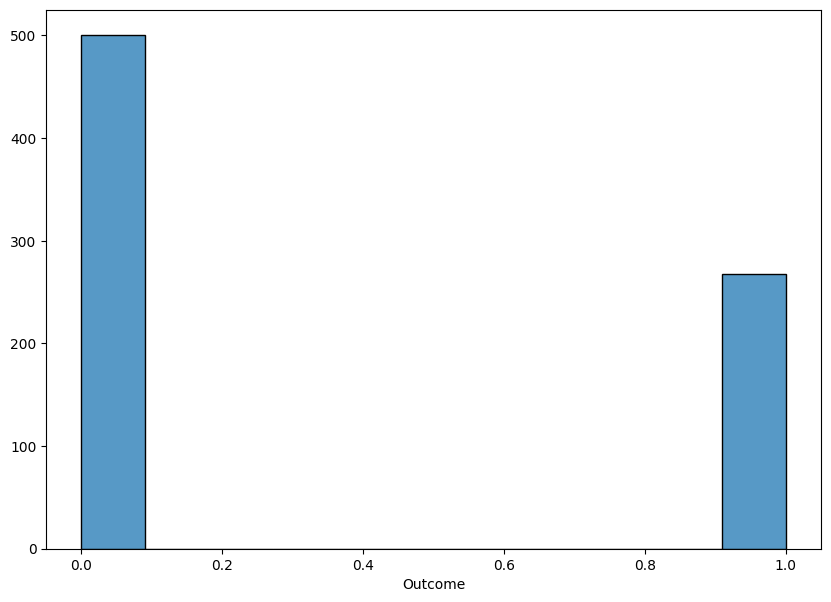

In [37]:
fig, axis = plt.subplots(1, figsize=(10, 7))
sns.histplot(ax=axis, data=df, x="Outcome").set(ylabel=None)

**Observaciones:**
> Value counts de Outcome muestra que la variable objetivo está desbalanceada: hay más observaciones sin diabetes (0) que con diabetes (1). Este desbalance puede afectar el rendimiento de los modelos si no se considera.

### (2) **Numéricas: Variables predictoras**

**Análisis Numérico-Categórico**

Se compara la distribución de los datos con la variable target 'Outcome'.

* **Separacion de variables en diferentes condiciones**

In [38]:
# Separo las variables en grupo 
medical_conditions = ['DiabetesPedigreeFunction', 'Glucose', 'BloodPressure', 'BMI']
person_id_vars = ['Pregnancies', 'Age']

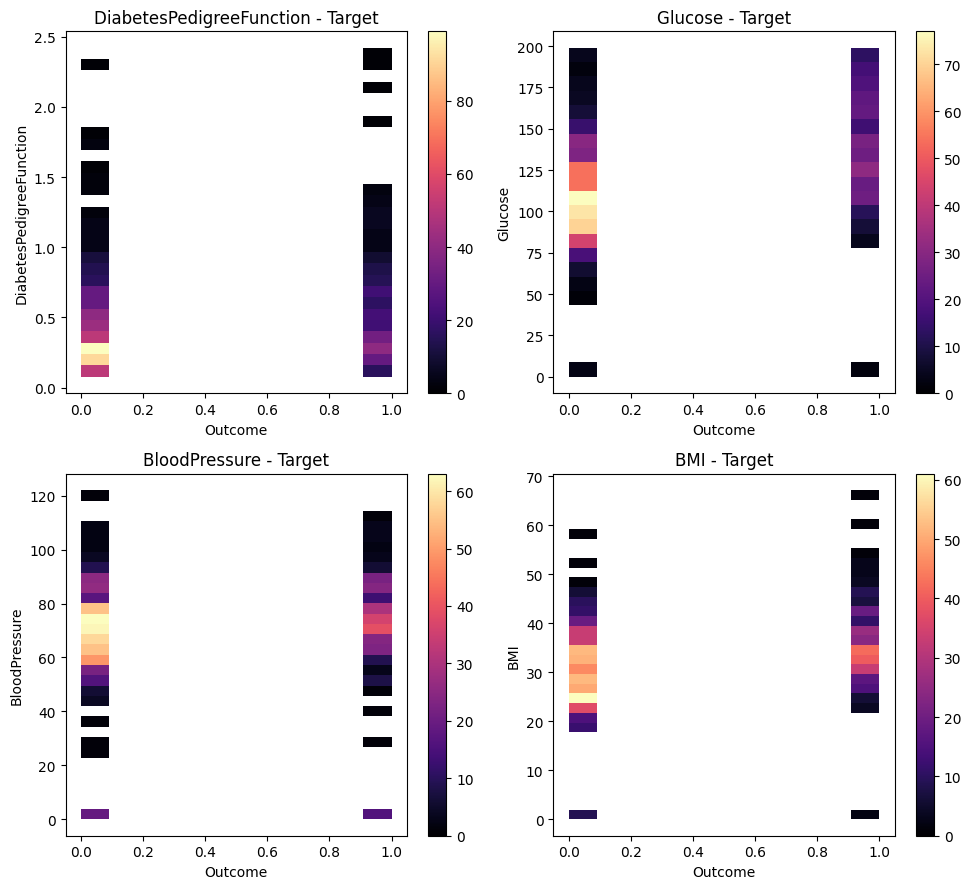

In [39]:
# La barra lateral represnta el conteo de datos con parámetro 'cbar'
import math 
# Gráficos para la información médica
n = len(medical_conditions)
cols_grid = 2                         
rows = math.ceil(n / cols_grid)   # math.ceil() calcula una divisón  y redondea a un numero entero
fig, axis = plt.subplots(rows,cols_grid, figsize=(10, 9))
axis = axis.flatten()
for i, columna in enumerate(medical_conditions):
    sns.histplot(data=df, x="Outcome", y=columna, cbar=True,ax=axis[i],cmap='magma')
    axis[i].set_title(f"{columna} - Target")

plt.tight_layout()
plt.show()


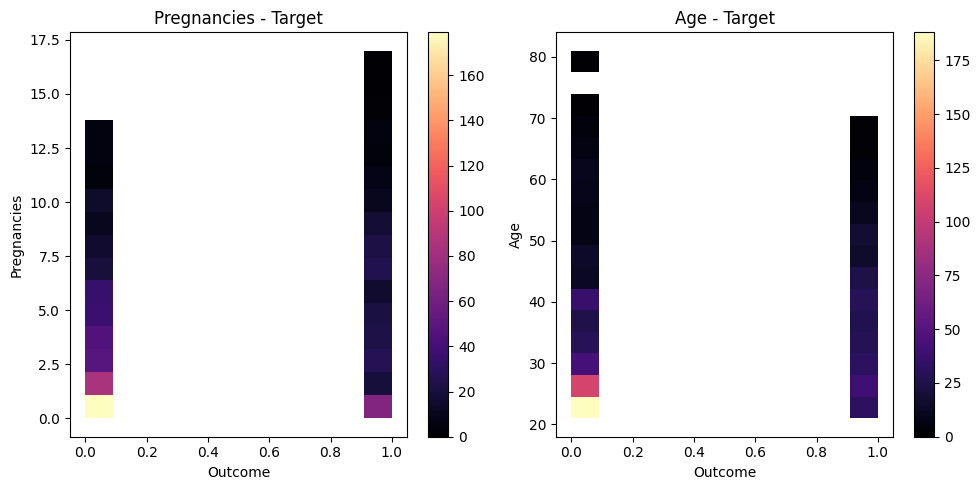

In [40]:
# Gráficos para la información personal
fig, axis = plt.subplots(1, 2, figsize=(10, 5))   

for i, columna in enumerate(person_id_vars):          
    sns.histplot(data=df, x="Outcome", y=columna, cbar=True, ax=axis[i],cmap='magma')
    axis[i].set_title(f"{columna} - Target")

plt.tight_layout()
plt.show()

**Observaciones:** La barra lateral represnta el conteo de datos. El color negro representa menor concentración de casos y el amarillo mayor número de casos.
> * ``Histograma de Pregnancies``, los emabrazos puedes aumentar el riesgo de desarrollar diabetes tipo 2 en el futuro. Este gráfico muestra cómo se distribuyen el número de embarazos en las observaciones. Se observa que la mayoría de pacientes tienen entre 0 y 5 embarazos registrados, con muy pocos valores altos y la mayoria de las paciemtes sí han estado embarazadas.
>  
> * ``DiabetesPedigreeFunction``, riesgo genético de tener diabetes. Hay más concentración de datos en las personas que están diagnosticadas sin la enfermedad tienen indices entre el 0.20 y 0.40
> 
> * ``Histograma de Glucose`` Esta gráfica representa la frecuencia de los valores de glucosa por muestra. Se puede apreciar que hay una concentración de valores por debajo de aproximadamente 140, con pocos casos extremadamente altos.”
> 
> * ``Histograma de BMI`` El índice de masa corporal (BMI) se concentra mayoritariamente entre aproximadamente 18 y 40. Esto indica que la mayoría de personas están en rango de sobrepeso según estas mediciones.

### (2) **Correlaciones**


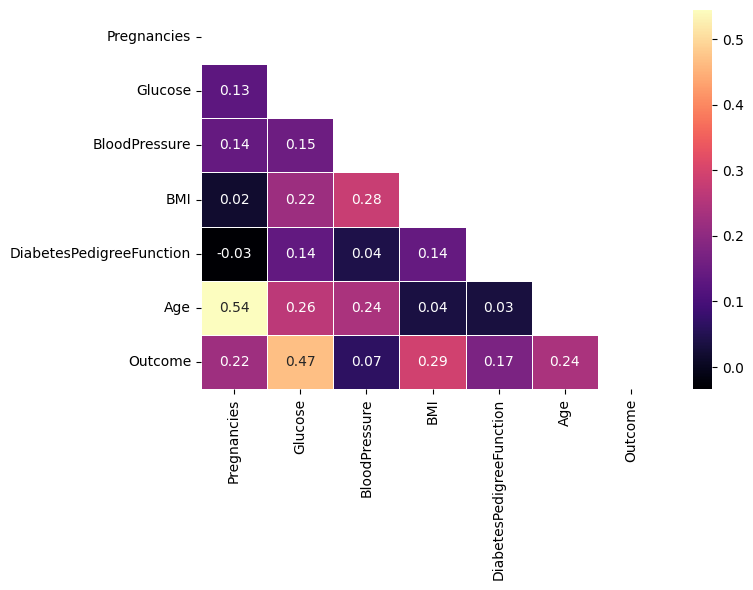

In [41]:
import numpy as np
import seaborn as sns

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f",cmap='magma')
plt.tight_layout()
plt.show()

**CONCLUSIONES:** La matriz de correlación muestra cómo se relacionan las variables entre sí. Por ejemplo, si aparecen colores más fuertes entre dos variables, esto indica correlación negativa.
* La columna más relacionada con el target es 'Glucosa'(0.47) seguida del peso corporal de la persona 'BMI'(0.29), 'Age' (0.24) y y el número de embarazos que ha tenido 'Pregnancies'(0.22)



## Paso 3: **Ingenieria de características (Outliers)**

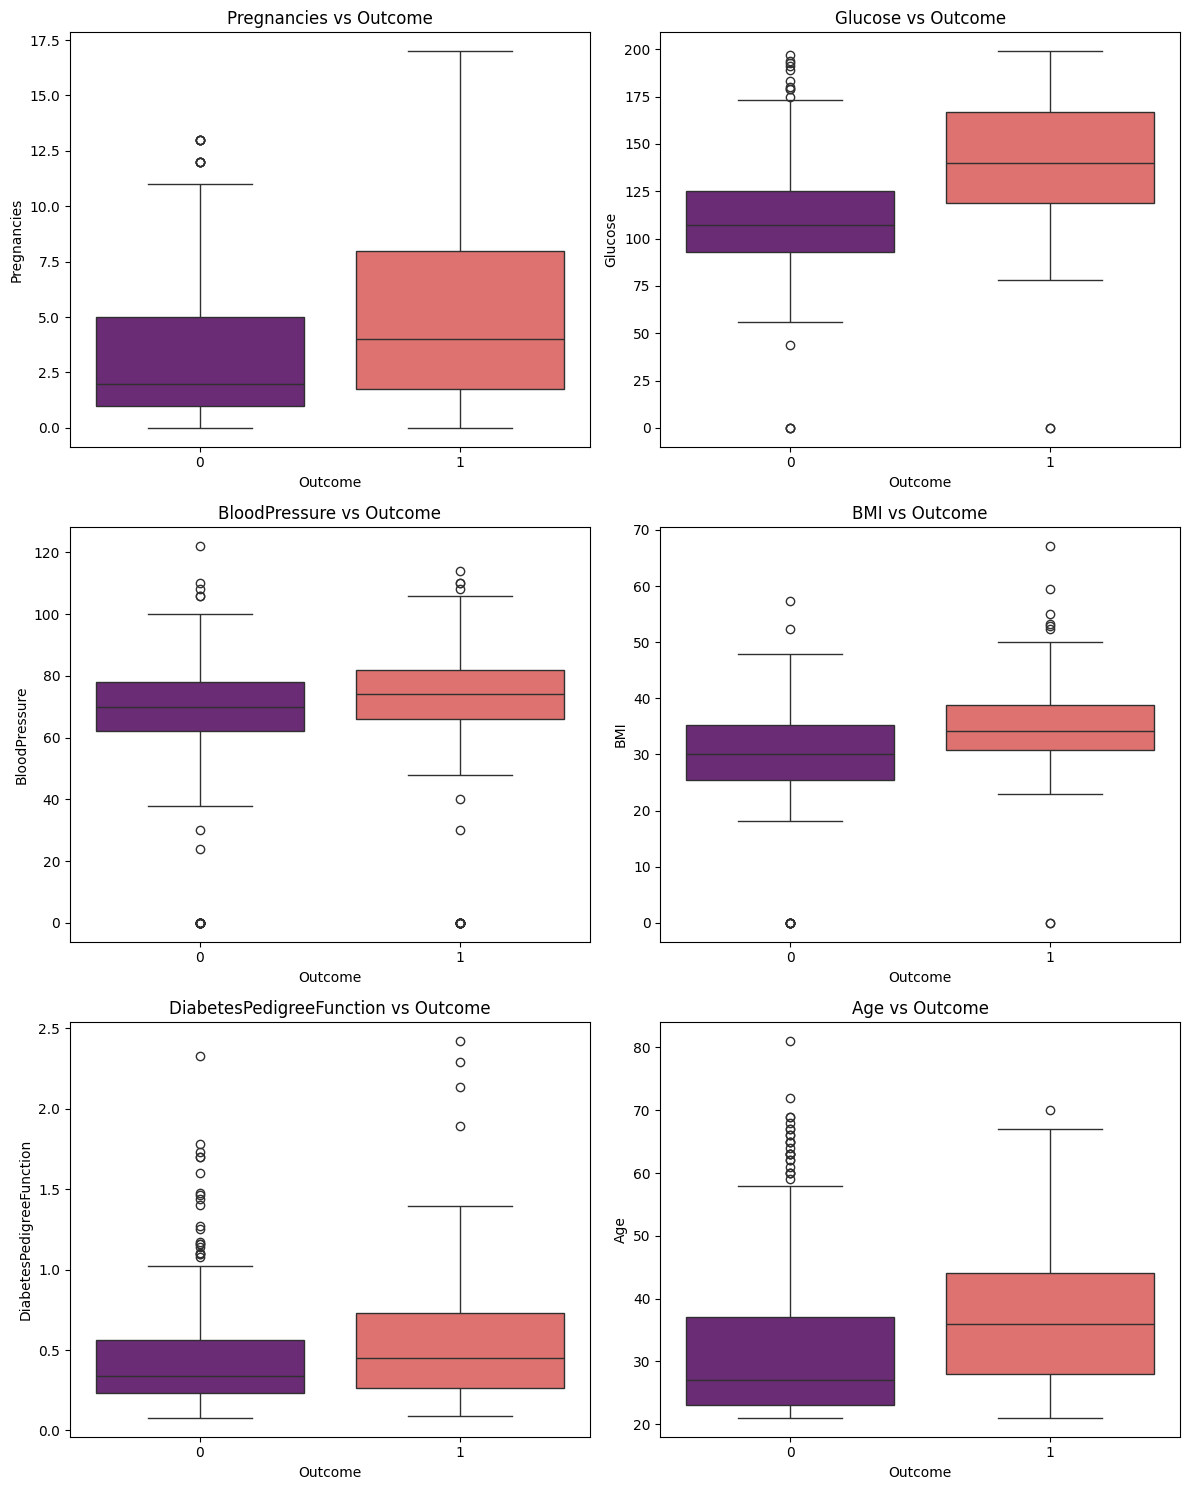

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

df = df.drop(df[(df['BMI'] == 0) & (df['Glucose'] == 0) & (df['BloodPressure'] == 0)].index)

features = df.columns.drop("Outcome")

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x="Outcome", y=col, ax=axes[i], palette="magma")
    axes[i].set_title(f"{col} vs Outcome")
    axes[i].set_xlabel("Outcome")
    axes[i].set_ylabel(col)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observaciones:**
> * Boxplot de Glucose vs Outcome:  
> En este boxplot se observa que los pacientes con Outcome = 1 (diabetes) tienden a tener valores de glucosa más altos que los de Outcome = 0 (sin diabetes). Esto indica una relación entre altos niveles de glucosa y diabetes.
>   
> * Boxplot de BMI vs Outcome:  
> El índice de masa corporal (BMI) parece ser mayor en la clase de pacientes con diabetes (1) comparado con la clase sin diabetes (0). Esto señala que BMI puede tener relación con la presencia de la enfermedad aunque para verificar esos casos necesitariamos conocer la altura de la persona.


## Paso 3: **Conclusión EDA**

El boxplot de Glucose vs Outcome muestra que los pacientes con diabetes tienen una mediana de glucosa más alta que los pacientes sin diabetes. Esto sugiere que mayores niveles de glucosa están asociados con mayor probabilidad de diagnóstico positivo.

## Paso 4: **Guardado de la data procesada**

In [43]:
# Saving processed data
df.to_csv("../data/processed/diabetes_eda.csv", index=False)

# **ML Random Forest**

Se utiliza para tareas de **clasificación** y **regresión**.

Es un tipo de aprendizaje que **ensamblan modelos** (model ensembling) para combinar las predicciones de múltiples árboles de decisión.

Cada árbol en un random forest se construye de manera independiente utilizando un **subconjunto aleatorio de los datos** de entrenamiento.

Luego, para hacer la predicción, cada árbol en el bosque hace su propia predicción y la **predicción final** se toma por **votación** de mayoría en el caso de clasificación, o **promedio** en el caso de regresión.

Este enfoque ayuda a superar el problema del sobreajuste, que es común con los árboles de decisión individuales.

## Paso 0: **Imports**

> - split para modelado       
>         from sklearn.model_selection import train_test_split, GridSearchCV

Se puede usar en ese proyecto? Cómo? --> EN ARBOLES NO INFLUYE EL ESCALADO POR LE TIPO DE AGORITMO, YA QUE ELEGE . SI USADO EN KNN O REGRESION LINEAL
> - Scaled | Escalado:    
>         from sklearn.preprocessing import StandardScaler, MinMaxScaler
> - Encoding | Codificación:   
>         from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

> - To save models       
        import json  
        import pickle
> - Feature Selection: Se puede usar en ese proyecto?-> DUDA cómo?      
>        from sklearn.feature_selection import SelectKBest

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pickle
from utils import get_classifier_metrics

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

## Paso 1: **Lectura de los datos procesados**

In [45]:
df = pd.read_csv('../data/processed/diabetes_eda.csv')
pd.DataFrame(df)

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1
...,...,...,...,...,...,...,...
763,10,101,76,32.9,0.171,63,0
764,2,122,70,36.8,0.340,27,0
765,5,121,72,26.2,0.245,30,0
766,1,126,60,30.1,0.349,47,1


In [46]:
df['Pregnancies'].max()

np.int64(17)

* **Observación:** 

> Dado que el valor de glucosa es un gran determinante para en análisis y lo normal sería menos de 100 de glucosa en sangre, filtro la columna copiando el resto de datos procesados para aproximar el resultado a mayores casos de predicción favorables.  


In [47]:
df = df[(df['Glucose'] >= 100)].copy()

## PASO 2: **Split data**

Definimos cual es la columna a predecir y que columnas utilizaremos como predictoras.

(Esta separacion deberia hacerse al principio antes de la imputacion de nulos y la transformacion de los datos pero por simplicidad haremos esta pequeña trampa de hacerlo luego.)

In [48]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## Paso 3: **Modelad** 

In [ ]:
rf_classifier_model = RandomForestClassifier(random_state=18)
rf_classifier_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

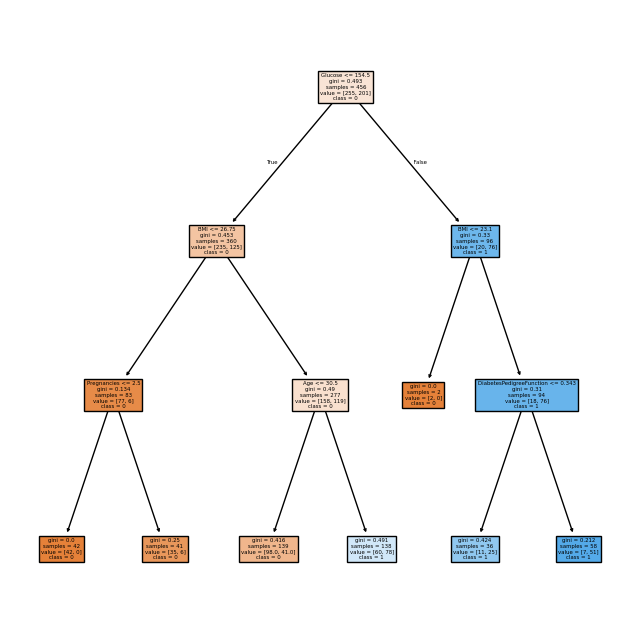

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(15, 15))

# Mostramos los 4 primeros árboles de los 100 generados (por defecto)
class_names = ["iris setosa", "iris versicolor", "iris virginica"]
tree.plot_tree(rf_classifier_model.estimators_[0], ax=axis[0, 0],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf_classifier_model.estimators_[1], ax=axis[0, 1],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf_classifier_model.estimators_[2], ax=axis[1, 0],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf_classifier_model.estimators_[3], ax=axis[1, 1],
               feature_names=list(X_train.columns), class_names=class_names, filled=True)

plt.show()

**Observaciones:**

> * Cada nodo muestra una regla (por ejemplo Glucose > X) y su contribución para clasificar a las observaciones como 0 o 1:  
> Empieza dividiendo por Grupo1: BMI<= 26.75 y Grupo 2: BMI<=23.1.  
> Grupo 1 se subdivide en Pregnancies y Age  
> Grupo 2 analiza Diabetes Pedigree

## Paso 4: **Predicción**

### (1) **DataFrame comparativo entre las predicciones y la data de testeo**

* Usamos X_test para predecir
* Análisis Overfitting con x_train vs X_test

In [ ]:
y_pred_test = rf_classifier_model.predict(X_test)
y_pred_test

array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1])

In [ ]:
len(y_pred_test)

In [ ]:
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test
pred_vs_real["predicciones"] = y_pred_test
pred_vs_real

,y_test,predicciones
114,1,1
142,0,0
511,0,0
175,1,1
339,1,1
...,...,...
138,0,0
752,0,0
470,0,0
267,0,0


In [ ]:
y_pred_train = rf_classifier_model.predict(X_train)
y_pred_train

In [ ]:
len(y_pred_train)

In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

Es importante considerar que este dataset es un problema de clasificación multiclase con tres clases (setosa, versicolor y virginica).

Al evaluar algunas metricas en un escenario multiclase, hay varias formas de promediar los resultados, siendo las más comunes "micro", "macro" y "weighted".

- Micro Average:
    - Es útil cuando las clases tienen un tamaño similar y cuando quieres tener en cuenta todas las instancias por igual.
    - Si aciertas 90/100 flores en total (sin importar la clase), el micro-avg es 0.90.
- Macro Average
    - Es adecuado cuando se quiere evaluar el rendimiento del modelo en cada clase de forma independiente y las clases son igualmente importantes.
    - Si la precisión es 0.90 (setosa), 0.80 (versicolor) y 0.70 (virginica), el macro-avg es (0.9 + 0.8 + 0.7) / 3 = 0.80.
- Weighted Average
    - Es ideal cuando las clases están desequilibradas y se quiere tener en cuenta el tamaño de cada clase en la evaluación global.
    - Similar al macro, pero cada precisión se multiplica por el número de muestras de esa clase antes de promediar.

### (2) **Moda como predictor base**

Aqui utilizaremos los predictores Dummy de sklearn que nos permiten exactamente eso tener una base contra la cual comparar nuestros resultados


In [54]:
predictor_mode = DummyClassifier(strategy='most_frequent')
predictor_mode.fit(X_train, y_train);

predicciones_mode = predictor_mode.predict(X_test)

accuracy_mode = accuracy_score(y_test, predicciones_mode)
print("Accuracy base:", accuracy_mode)

Accuracy base: 0.5565217391304348


## Paso 5: **Métricas e hiperparametrización**

In [ ]:
# Definir hiperparámetros a probar
param_diabetes = {'n_estimators': [50, 100, 200],
                   'max_depth': [3, 5, 10],
                   'min_samples_split': [2, 5, 10],
                   'min_samples_leaf': [1, 2, 4]}

# Implementar GridSearchCV
grid_diabetes = GridSearchCV(RandomForestClassifier(random_state=18),
                                param_diabetes,
                                cv=5,
                                n_jobs=-1,
                                verbose=1)

# Entrenamos
grid_diabetes.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
grid_diabetes.best_params_

### (1) **Métricas del modelo de Clasificación** revisa - cambia

* **Accuracy**

In [55]:
from sklearn.metrics import accuracy_score

accuracy= accuracy_score(y_test, y_pred,normalize=False)
print("Accuracy Arbol:", accuracy)

Accuracy Arbol: 88.0


* **Precision score**

In [56]:
print(precision_score(y_test, y_pred,average='micro'))

0.7652173913043478


* **GridScearchCV: Overfitting**

https://4geeks.com/es/lesson/optimizacion-de-hiperparametros-del-modelo 

In [ ]:
hyperparams = {'n_estimators': [50, 100, 200],'max_depth': [3, 5, 10],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

# Inicializamos la cuadrícula
grid = GridSearchCV(RandomForestClassifier(random_state=18),hyperparams,cv=5,n_jobs=-1,verbose=1)
print(grid)

GridSearchCV(cv=5,
             estimator=     Pregnancies  Glucose  ...  Age  Outcome
0              6      148  ...   50        1
2              8      183  ...   32        1
4              0      137  ...   33        1
5              5      116  ...   30        0
7             10      115  ...   29        0
..           ...      ...  ...  ...      ...
761            9      170  ...   43        1
763           10      101  ...   63        0
764            2      122  ...   27        0
765            5      121  ...   30        0
766            1      126  ...   47        1

[571 rows x 7 columns],
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')


* **Cassification report**

In [ ]:
print(classification_report(y_test, y_pred)) # DUDA QUE SIGNIFCIAN LOS NUMEROS - INVESTIGAR Y ELEGIR UNA METRICA(ej:ACCURACY)
# probar una a una: precision, recall, ...

              precision    recall  f1-score   support

           0       0.85      0.70      0.77        64
           1       0.69      0.84      0.76        51

    accuracy                           0.77       115
   macro avg       0.77      0.77      0.77       115
weighted avg       0.78      0.77      0.77       115



### (2) **Matriz de confusión**

DUDA::: Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado

In [61]:
matrix = confusion_matrix(y_test, y_pred)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy por clase: [0.703125   0.84313725]


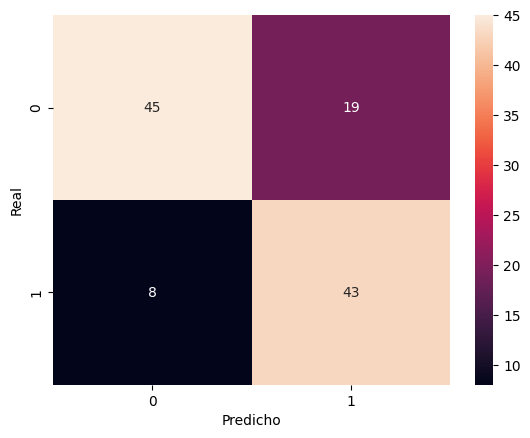

In [62]:
confussion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

**OBSERVACIONES:**

> Matriz de confusión: Esta matriz muestra cuántos valores se clasificaron correctamente o incorrectamente. Los valores diagonales representan aciertos y los otros representan errores.
DUDA--> CAMBIAR REPORTE

### (2.1) **Matriz de confusión para la predicción en base a la moda**

In [63]:
matrix_moda = confusion_matrix(y_test, predicciones_mode)
print("Accuracy por clase:", matrix_moda.diagonal()/matrix_moda.sum(axis=1))

Accuracy por clase: [1. 0.]


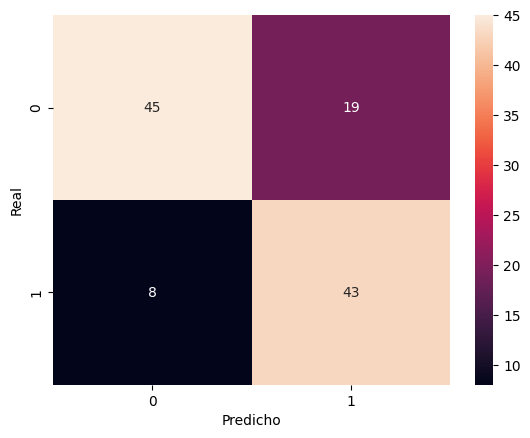

In [64]:
confussion_matrix_mode = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix_mode, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

**OBSERVACIONES DE LAS MATRICES DE CONFUSIÓN:**

>Accuracy / Reporte de clasificación--- DUDA

> Este resultado es bueno o es malo?
> 
> Como saber si mi prediccion es buena o mala?
> 
> - 90% de Accuracy (u otra metrica) es bueno?
> - 30% de Accuracy (u otra metrica) es malo?
> 
> Todo es relativo, cual es el accuracy actual en el negocio? Que se utiliza actualmente para hacer la prediccion? Podemos comparar contra eso? Lo mejoramos o no?
> 
> Lo mas recomendado es establecer una base, si el negocio ya la tiene podemos empezar por alli si no podemos utilizar la media o la moda como predictor base dependiendo si la variable a predecir es numerica o categorica respectivamente.

## Paso 6: **Guardado del modelo**

In [ ]:
with open('../../models/iris-decision-tree-classifier.pkl', 'wb') as file:
    pickle.dump(dt_classifier_model, file)

FileNotFoundError: [Errno 2] No such file or directory: '../../models/iris-decision-tree-classifier.pkl'